# Notebook 02 — Exploratory Data Analysis (EDA)
## Goal: Answer key business questions using data
**Source:** master_clean.csv (cleaned & merged dataset)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


master = pd.read_csv("../data/processed/master_clean.csv")


date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

print(" Master Data Loaded!")
print(f"Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")

 Master Data Loaded!
Shape: 119,143 rows × 28 columns


##  Question 1 — Order Trend Analysis
Business Question:
"How has our business grown month by month? Are we growing or declining?"

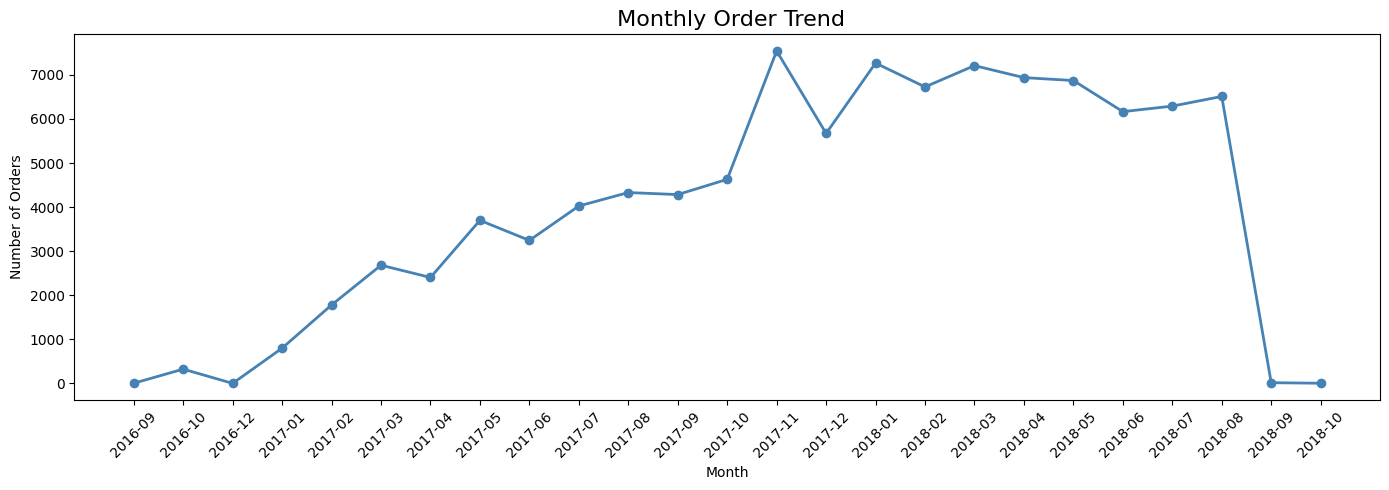

 Peak month: 2017-11
 Peak orders: 7,544


In [14]:
# Monthly Order Trend

master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = master.groupby('order_month')['order_id'].nunique().reset_index()
monthly_orders.columns = ['month', 'order_count']
monthly_orders['month'] = monthly_orders['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['month'], monthly_orders['order_count'], 
         marker='o', color='steelblue', linewidth=2)
plt.title(' Monthly Order Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/01_monthly_order_trend.png', dpi=150)
plt.show()

print(f" Peak month: {monthly_orders.loc[monthly_orders['order_count'].idxmax(), 'month']}")
print(f" Peak orders: {monthly_orders['order_count'].max():,}")

## Question 2 — Order Status Breakdown

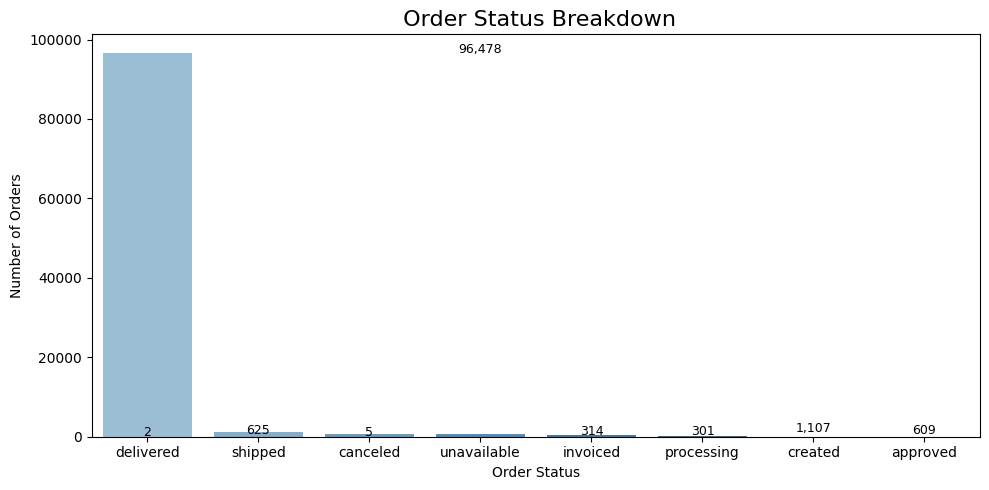

 Order Status Percentages:
  delivered            → 96,478 (97.0%)
  shipped              → 1,107 (1.1%)
  canceled             → 625 (0.6%)
  unavailable          → 609 (0.6%)
  invoiced             → 314 (0.3%)
  processing           → 301 (0.3%)
  created              → 5 (0.0%)
  approved             → 2 (0.0%)


In [3]:
# ── QUESTION 2 — Order Status Breakdown ──────


status_counts = master.groupby('order_status')['order_id'].nunique().reset_index()
status_counts.columns = ['status', 'count']
status_counts = status_counts.sort_values('count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=status_counts, x='status', y='count', palette='Blues_d')
plt.title(' Order Status Breakdown', fontsize=16)
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
for i, row in status_counts.iterrows():
    plt.text(i, row['count'] + 100 , f"{row['count']:,}", 
             ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/02_order_status.png', dpi=150)
plt.show()

# Percentage breakdown
total = status_counts['count'].sum()
print(" Order Status Percentages:")
for _, row in status_counts.iterrows():
    print(f"  {row['status']:20s} → {row['count']:,} ({row['count']/total*100:.1f}%)")

##  Question 3 — Peak Business Hours

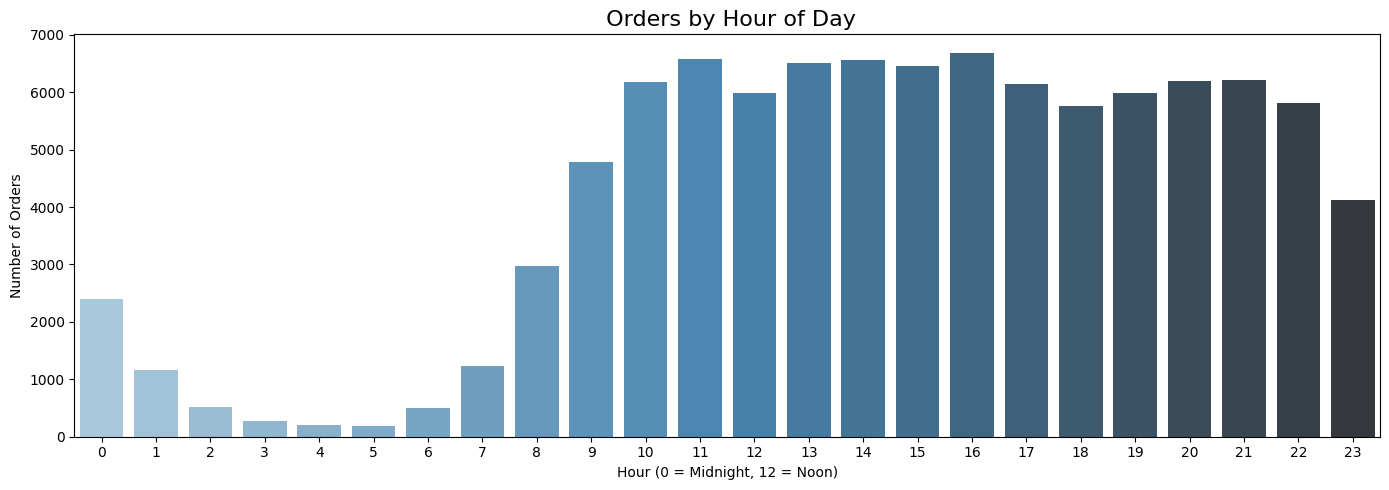

 Peak ordering hour: 16:00


In [4]:
# Peak Ordering Hours 

master['order_hour'] = master['order_purchase_timestamp'].dt.hour

hourly_orders = master.groupby('order_hour')['order_id'].nunique().reset_index()
hourly_orders.columns = ['hour', 'order_count']

plt.figure(figsize=(14, 5))
sns.barplot(data=hourly_orders, x='hour', y='order_count', palette='Blues_d')
plt.title(' Orders by Hour of Day', fontsize=16)
plt.xlabel('Hour (0 = Midnight, 12 = Noon)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../visuals/03_peak_hours.png', dpi=150)
plt.show()

peak_hour = hourly_orders.loc[hourly_orders['order_count'].idxmax(), 'hour']
print(f" Peak ordering hour: {peak_hour}:00")

##  Question 4 — Peak Days of Week

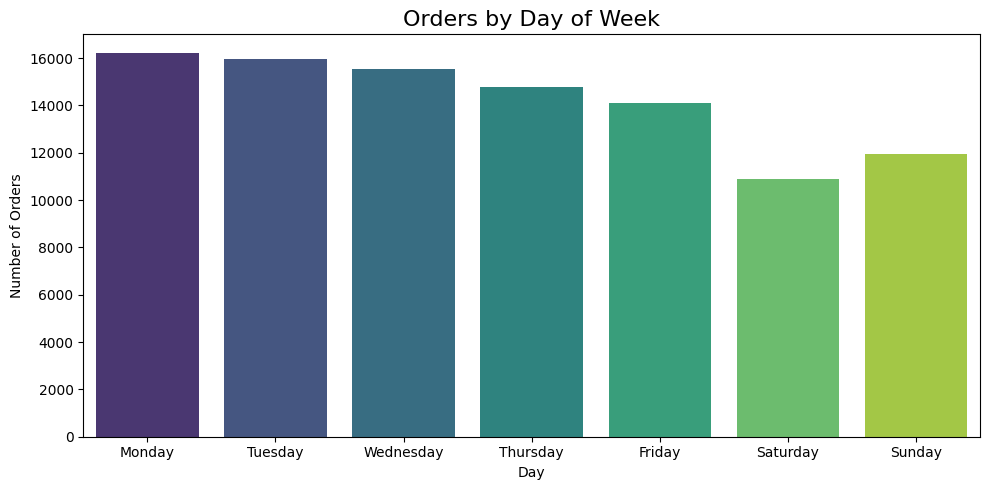

 Busiest day: Monday


In [5]:
# ── QUESTION 4 — Peak Days of Week ───────────

master['order_day'] = master['order_purchase_timestamp'].dt.day_name()

# Define correct order for days
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily_orders = master.groupby('order_day')['order_id'].nunique().reset_index()
daily_orders.columns = ['day', 'order_count']
daily_orders['day'] = pd.Categorical(daily_orders['day'], categories=day_order, ordered=True)
daily_orders = daily_orders.sort_values('day')

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_orders, x='day', y='order_count', palette='viridis')
plt.title('Orders by Day of Week', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../visuals/04_peak_days.png', dpi=150)
plt.show()

peak_day = daily_orders.loc[daily_orders['order_count'].idxmax(), 'day']
print(f" Busiest day: {peak_day}")

## Question 5 — Delivery Time Analysis

 DELIVERY TIME STATISTICS:
  Average : 12.0 days
  Median  : 10.0 days
  Fastest : 0.0 days
  Slowest : 209.0 days


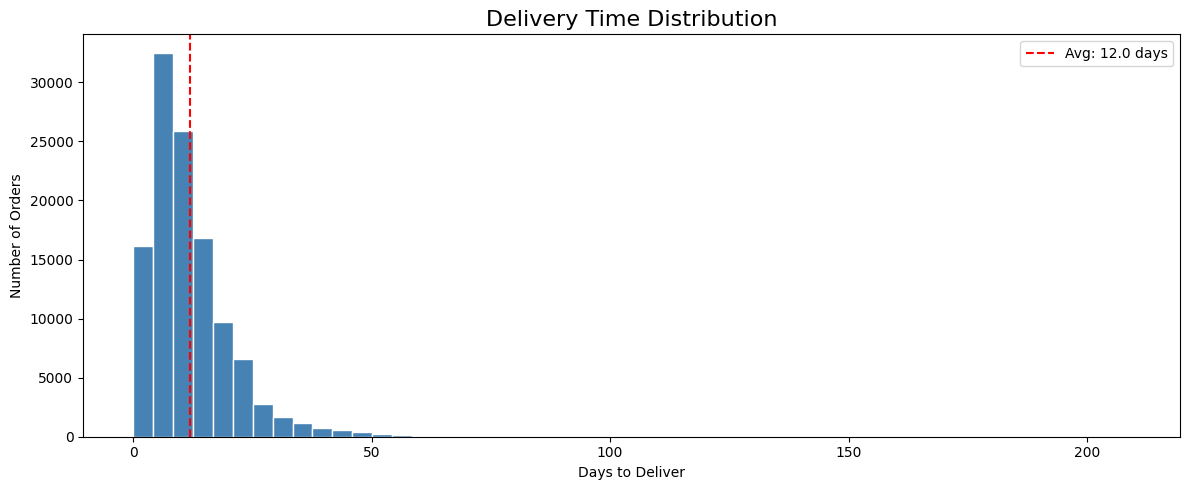

In [6]:
# ── QUESTION 5 — Delivery Time Analysis ──────

# Only look at delivered orders
delivered = master[master['order_status'] == 'delivered'].copy()

# Calculate delivery days
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_purchase_timestamp']
).dt.days

# Summary stats
print(" DELIVERY TIME STATISTICS:")
print(f"  Average : {delivered['delivery_days'].mean():.1f} days")
print(f"  Median  : {delivered['delivery_days'].median():.1f} days")
print(f"  Fastest : {delivered['delivery_days'].min()} days")
print(f"  Slowest : {delivered['delivery_days'].max()} days")

# Plot histogram
plt.figure(figsize=(12, 5))
plt.hist(delivered['delivery_days'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Delivery Time Distribution', fontsize=16)
plt.xlabel('Days to Deliver')
plt.ylabel('Number of Orders')
plt.axvline(delivered['delivery_days'].mean(), color='red', 
            linestyle='--', label=f"Avg: {delivered['delivery_days'].mean():.1f} days")
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/05_delivery_time.png', dpi=150)
plt.show()

##  Question 6 — Late Deliveries


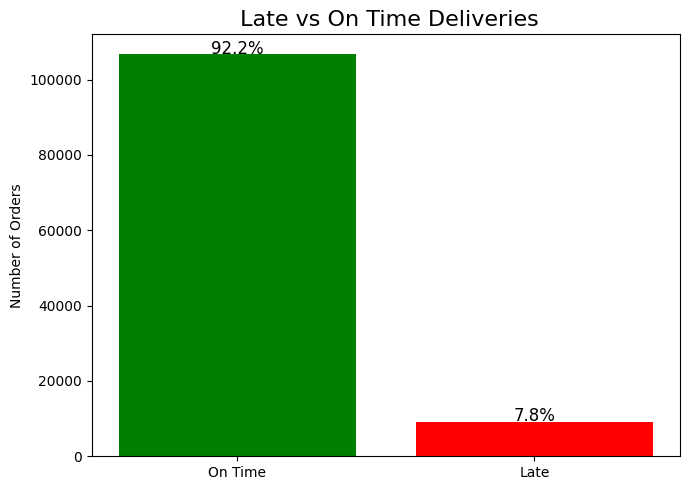

In [7]:
# ── QUESTION 6 — Late vs On Time Deliveries ──


delivered['delivery_status'] = delivered.apply(
    lambda row: 'Late' 
    if row['order_delivered_customer_date'] > row['order_estimated_delivery_date'] 
    else 'On Time', axis=1
)

status_count = delivered['delivery_status'].value_counts().reset_index()
status_count.columns = ['status', 'count']

# Plot
plt.figure(figsize=(7, 5))
colors = ['green' if s == 'On Time' else 'red' for s in status_count['status']]
plt.bar(status_count['status'], status_count['count'], color=colors)
plt.title(' Late vs On Time Deliveries', fontsize=16)
plt.ylabel('Number of Orders')
for i, row in status_count.iterrows():
    pct = row['count'] / status_count['count'].sum() * 100
    plt.text(i, row['count'] + 200, f"{pct:.1f}%", ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/06_late_deliveries.png', dpi=150)
plt.show()

##  Question 7 — Review Score Distribution

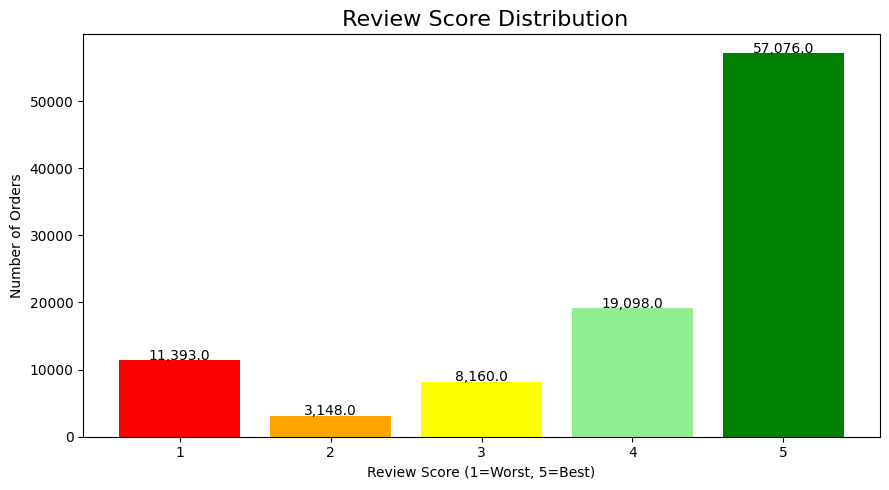

 Average Review Score: 4.02 / 5.00


In [15]:
# Review Score Distribution

review_counts = master.groupby('review_score')['order_id'].nunique().reset_index()
review_counts.columns = ['score', 'count']

plt.figure(figsize=(9, 5))
colors = ['red','orange','yellow','lightgreen','green']
plt.bar(review_counts['score'], review_counts['count'], color=colors)
plt.title(' Review Score Distribution', fontsize=16)
plt.xlabel('Review Score (1=Worst, 5=Best)')
plt.ylabel('Number of Orders')
for i, row in review_counts.iterrows():
    plt.text(row['score'], row['count'] + 100, 
             f"{row['count']:,}", ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../visuals/07_review_scores.png', dpi=150)
plt.show()

avg_score = master['review_score'].mean()
print(f" Average Review Score: {avg_score:.2f} / 5.00")

## Question 8 — Payment Method Analysis

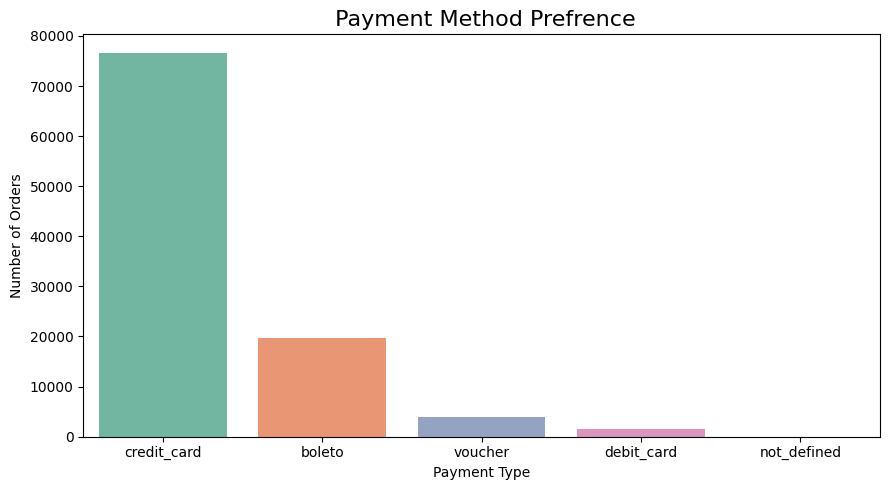

Avg credit card installments: 3.6


In [9]:
payments_counts = master.groupby('payment_type')['order_id'].nunique().reset_index()
payments_counts.columns =['payment_type','count']
payments_counts = payments_counts.sort_values('count',ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(data=payments_counts, x='payment_type', y='count', palette='Set2')
plt.title(' Payment Method Prefrence', fontsize=16)
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../visuals/08_payments_methods.png', dpi=150)
plt.show()


# Average installments for credit card
cc = master[master['payment_type'] == 'credit_card']
print(f"Avg credit card installments: {cc['payment_installments'].mean():.1f}")


##  Question 9 — Revenue by Month

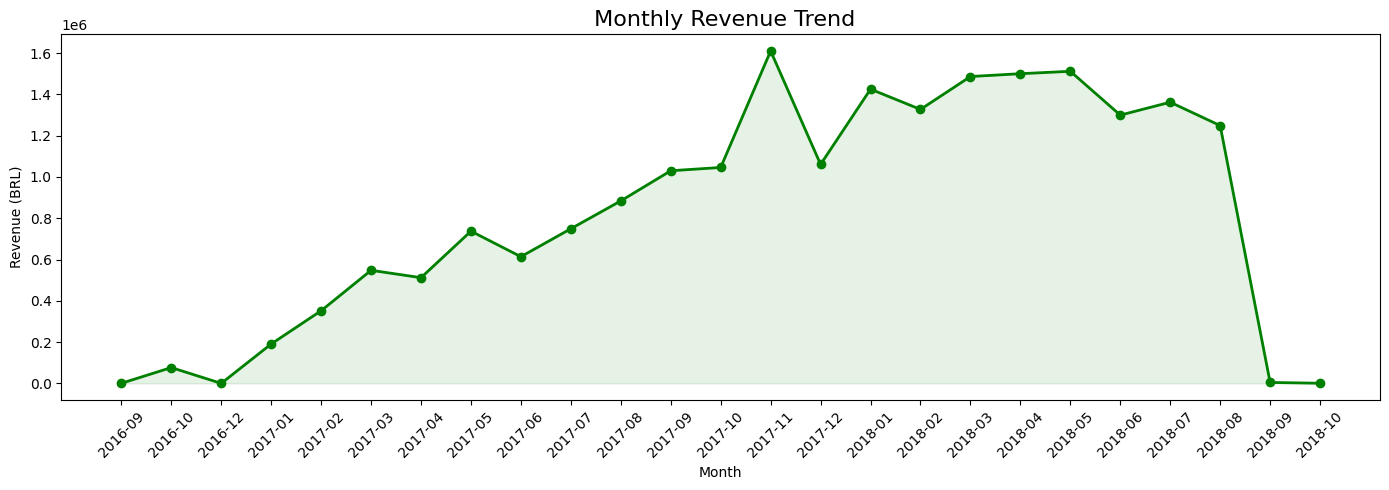

Total Revenue: R$ 20,579,664.01
 Peak Revenue Month: 2017-11


In [10]:
monthly_revenue = master.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue.columns = ['month', 'revenue']
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'],
         marker='o', color='green', linewidth=2)

plt.title(' Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(range(len(monthly_revenue)), monthly_revenue['month'], rotation=45)
plt.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'], 
                 alpha=0.1, color='green')
plt.tight_layout()
plt.savefig('../visuals/09_monthly_revenue.png', dpi=150)
plt.show()

total_rev = monthly_revenue['revenue'].sum()
peak_rev_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax(), 'month']
print(f"Total Revenue: R$ {total_rev:,.2f}")
print(f" Peak Revenue Month: {peak_rev_month}")

## Question 10 — Top Product Categories by Revenue

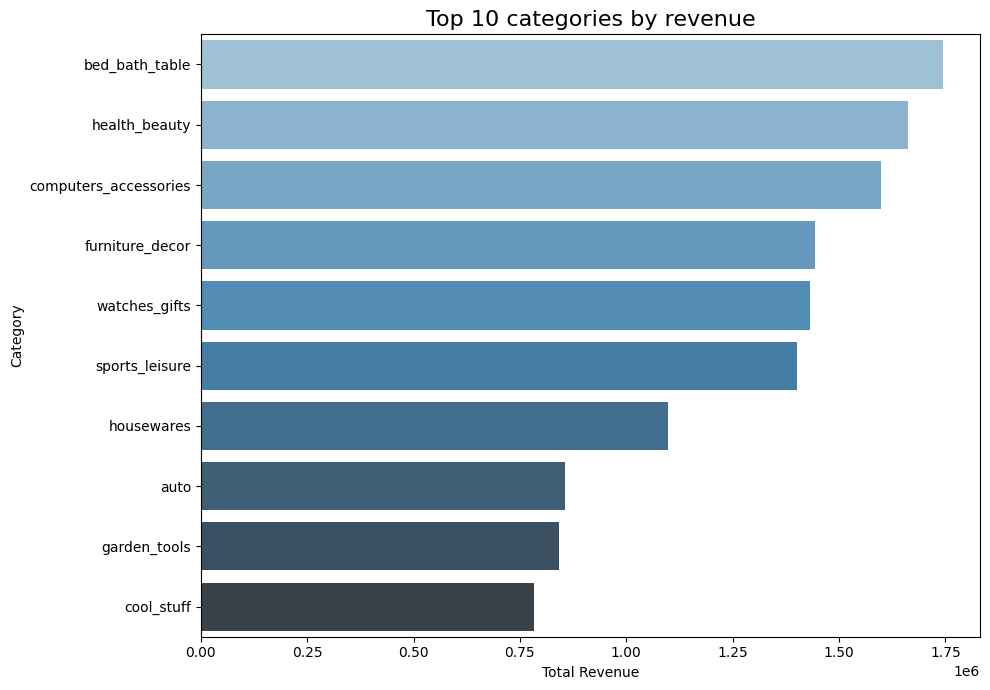

 Top 5 Categories:
  bed_bath_table                      → R$ 1,743,999
  health_beauty                       → R$ 1,662,964
  computers_accessories               → R$ 1,599,481
  furniture_decor                     → R$ 1,443,964
  watches_gifts                       → R$ 1,430,553


In [11]:
category_revenue = master.groupby('product_category_name_english')['payment_value'].sum().reset_index()
category_revenue.columns =['category', 'revenue']
category_revenue = category_revenue.sort_values('revenue',ascending=False).head(10)

plt.figure(figsize=(10,7))
sns.barplot(data=category_revenue, y='category',x='revenue', palette='Blues_d')
plt.title('Top 10 categories by revenue', fontsize=16)
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('../visuals/10_top_categories.png', dpi=150)
plt.show()

print(" Top 5 Categories:")
for _, row in category_revenue.head(5).iterrows():
    print(f"  {row['category']:35s} → R$ {row['revenue']:,.0f}")

In [12]:
## # ── EDA SUMMARY — KEY BUSINESS INSIGHTS ──────
print("=" * 55)
print(" EDA COMPLETE — KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"""
1.  GROWTH    : Business grew consistently through 2017-2018
2.  DELIVERY  : Avg delivery time is 12 days
3.  LATE      : 7.8% of orders arrive late — needs attention
4.  REVIEWS   : Average score 4.02/5 — customers mostly satisfied
5.  PAYMENTS  : Credit card dominates — avg 3.6 installments
6.  REVENUE   : Peak month was 2017-11 — likely seasonal pattern
7.  CATEGORY  : Top category drives highest revenue
""")

 EDA COMPLETE — KEY BUSINESS INSIGHTS

1.  GROWTH    : Business grew consistently through 2017-2018
2.  DELIVERY  : Avg delivery time is 12 days
3.  LATE      : 7.8% of orders arrive late — needs attention
4.  REVIEWS   : Average score 4.02/5 — customers mostly satisfied
5.  PAYMENTS  : Credit card dominates — avg 3.6 installments
6.  REVENUE   : Peak month was 2017-11 — likely seasonal pattern
7.  CATEGORY  : Top category drives highest revenue

